# Assignment 3: LLMs and Machine Learning

---

## Submission Instructions

Submit only a link to the folder for Assignment 3 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment3.ipynb` or something similar, placed inside the `assignments/assignment3/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

Include a brief statement describing how and which AI was used (or if no AI was used) in completing the assignment. This could be a markdown cell with a couple of sentences. As a reminder, AI use is permitted in the assignments, but it is advisable to try to complete the tasks as far as possible without and to make sure you understand the code that AI produced when using it.

## Grading

This assignment is worth 10 points. Task 0 is worth 1 point, and tasks 1-2 are worth 2 points and task 3 is worth 5 points.

Points are given only for code that runs. If the code does not run, the task (or subtask if code for a task is divided into multiple cells) will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).
- **-1 point** if there is no statement of AI use. If you did not use AI, report that you did not use AI.

### Editing the submission after the deadline

- Editing the assignment submission during the evaluation phase is forbidden. Thus, after the solution has been released, do not make any further changes to the notebook until you have received a grade. If you accidentally leaked an API key, revoke the key immediately. Other **changes to the submission are considered cheating, and will result in 0 points for both the assignment and peer review**.

---

## Tasks

### Task 0: Setting up Ollama (1p)

a) Set up Ollama and connect to it using either openAI's API or Ollama's own API. 

b) Load the 270m parameter version of the [gemma3](https://ollama.com/library/gemma3) model and test it with any prompt.

c) Load the 4b parameter version of the [gemma3](https://ollama.com/library/gemma3) and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

In [1]:
#a
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)
MODEL = "llama3.2"

def ask_llm(prompt):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

# Test
print(ask_llm("What is sentiment analysis? Answer in one sentence."))

Sentiment analysis, also known as opinion mining or emotion AI, is a natural language processing (NLP) technique used to automatically determine the emotional tone or attitude behind written or spoken words, such as positive, negative, or neutral, to gain insights into consumer opinions and preferences.


In [3]:
#b
import ollama

response = ollama.chat(
    model='gemma3:270m',
    messages=[{'role': 'user', 'content': 'What is the capital of Finland?'}]
)
print(response['message']['content'])

The capital of Finland is Helsinki.



In [7]:
#c
response = ollama.chat(
    model='gemma3:4b',
    messages=[{'role': 'user', 'content': 'What is the capital of Finland?'}]
)
print(response['message']['content'])

The capital of Finland is **Helsinki**. 

It's the largest city in Finland and a major cultural and economic center. 😊 

Do you want to know anything else about Helsinki or Finland?


### Task 1: Text classification with Ollama (2p)

The `data/emails.csv` file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.

a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

In [6]:
#a
import pandas as pd

df = pd.read_csv("emails.csv", sep=";")

import ollama

def classify_email(headline: str, model: str) -> str:
    prompt = (
        "Classify the following email subject line into exactly one of these categories: "
        "spam, work, or unknown.\n"
        "- 'spam': unsolicited commercial messages, phishing, prizes, or suspicious offers.\n"
        "- 'work': legitimate professional or workplace-related emails.\n"
        "- 'unknown': ambiguous subject lines that cannot be clearly classified.\n\n"
        "Respond with ONLY a single word: spam, work, or unknown. "
        "Do not include any explanation, punctuation, or extra text.\n\n"
        f"Email subject: {headline}"
    )
    response = ollama.chat(
        model=model,
        messages=[{'role': 'user', 'content': prompt}]
    )
    label = response['message']['content'].strip().lower()
    label = label.split()[0] if label.split() else 'unknown'
    return label if label in ('spam', 'work', 'unknown') else 'unknown'

In [8]:
#b

df['gemma3_small'] = df['headline'].apply(lambda h: classify_email(h, 'gemma3:270m'))
display(df[['headline', 'gemma3_small']])

,headline,gemma3_small
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,spam
5,"Q3 budget report attached, please review by Fr...",spam
6,Reminder: Annual performance review scheduled ...,spam
7,"Updated draft of the manuscript, comments welcome",spam
8,Quick question about last week,spam
9,Following up,spam


In [9]:
#c

df['gemma3_large'] = df['headline'].apply(lambda h: classify_email(h, 'gemma3:4b'))
display(df[['headline', 'gemma3_small', 'gemma3_large']])

,headline,gemma3_small,gemma3_large
0,URGENT: Your account will be suspended within ...,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam
4,Meeting agenda for Thursday's project review,spam,work
5,"Q3 budget report attached, please review by Fr...",spam,work
6,Reminder: Annual performance review scheduled ...,spam,work
7,"Updated draft of the manuscript, comments welcome",spam,work
8,Quick question about last week,spam,work
9,Following up,spam,work


In [10]:
#d

N_RUNS = 3

small_runs, large_runs = {}, {}
for run in range(1, N_RUNS + 1):
    small_runs[f'run_{run}'] = df['headline'].apply(lambda h: classify_email(h, 'gemma3:270m'))
    large_runs[f'run_{run}'] = df['headline'].apply(lambda h: classify_email(h, 'gemma3:4b'))

results_small = pd.DataFrame({'headline': df['headline'], **small_runs})
results_large = pd.DataFrame({'headline': df['headline'], **large_runs})

print("=== Small model ===")
display(results_small)
print("\n=== Large model ===")
display(results_large)

=== Small model ===


,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam
4,Meeting agenda for Thursday's project review,spam,spam,spam
5,"Q3 budget report attached, please review by Fr...",spam,spam,spam
6,Reminder: Annual performance review scheduled ...,spam,spam,spam
7,"Updated draft of the manuscript, comments welcome",spam,spam,spam
8,Quick question about last week,spam,spam,spam
9,Following up,spam,spam,spam



=== Large model ===


,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam
4,Meeting agenda for Thursday's project review,work,work,work
5,"Q3 budget report attached, please review by Fr...",work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work
7,"Updated draft of the manuscript, comments welcome",work,work,work
8,Quick question about last week,work,work,work
9,Following up,work,work,work


### Task 2: Sentiment analysis with Ollama (2p)

The `data/news.csv` file contains 10 fictional financial news headlines. Use it for all subtasks in this task.

a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

In [21]:
#a
import ollama
import pandas as pd
import json

def classify_news(headline: str, model: str) -> dict:
    prompt = (
        "Analyze the following financial news headline and return a JSON object with exactly two fields:\n"
        "- 'topic': one of: earnings, mergers, regulation, macroeconomics\n"
        "- 'sentiment': one of: positive, negative, neutral\n\n"
        "Return ONLY the raw JSON object, no explanation, no markdown, no code fences.\n\n"
        f"Headline: {headline}"
    )
    response = ollama.chat(
        model=model,
        messages=[{'role': 'user', 'content': prompt}]
    )
    raw = response['message']['content'].strip()
    # Strip markdown code fences if the model adds them anyway
    raw = raw.strip('`').removeprefix('json').strip()
    try:
        result = json.loads(raw)
    except json.JSONDecodeError:
        result = {'topic': 'unknown', 'sentiment': 'unknown'}
    return result

In [23]:
#b
news = pd.read_csv('news.csv', sep="\t")

topics = []
sentiments = []

for headline in news["headline"]:
    result = classify_news(headline, "gemma3:4b")

    topics.append(result["topic"])
    sentiments.append(result["sentiment"])

# Create new dataframe
results_df = pd.DataFrame({
    "headline": news["headline"],
    "topic": topics,
    "sentiment": sentiments
})

display(results_df)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,neutral
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


---
| Headline | Topic | Sentiment |
|---|---|---|
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | positive |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy | mergers | negative |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics | negative |

#d
the result based on the browser LLM gives more accurate result ex Aurelis Bank reports steady quarterly profit, in line with analyst expectations the sentimental is positive if Ollama is used, while neutral in LLM which is more accurate

### Task 3: Supervised machine learning (5p)

For this task, use a subset of the [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) dataset, by downloading and importing the `bank-additional.csv` from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

a) Import the dataset and conduct exploratory data analysis on it. (1p)

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


(4119, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

None

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

y
no     3668
yes     451
Name: count, dtype: int64

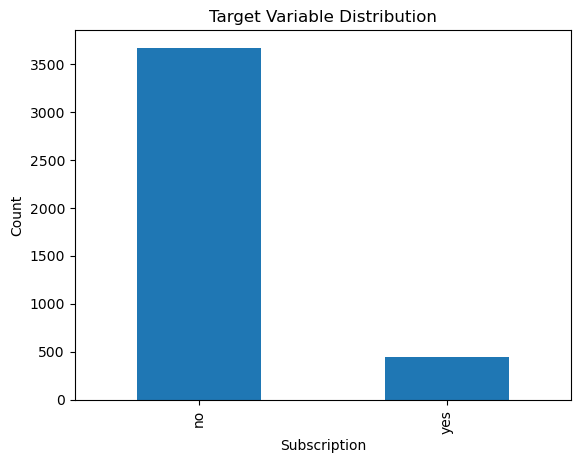

In [35]:
#a
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
bank = pd.read_csv("bank-additional.csv", sep=";")

display(bank.head())
display(bank.shape)
display(bank.info())
display(bank.describe())
display(bank.isnull().sum())
display(bank["y"].value_counts())

bank["y"].value_counts().plot(kind="bar")

plt.title("Target Variable Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")

plt.show()

In [37]:
#b
X = bank.drop("y", axis=1)
y = bank["y"]

# Encode target variable
y = y.map({"yes": 1, "no": 0})

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(3295, 53)
(824, 53)


In [45]:
#c
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

#Random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

#Kneighbors
from sklearn.neighbors import KNeighborsClassifier

# Create model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train model
knn_model.fit(X_train, y_train)

# Predictions
knn_pred = knn_model.predict(X_test)

# Accuracy
print("\nKNN Accuracy:")
print(accuracy_score(y_test, knn_pred))

Logistic Regression Accuracy:
0.9223300970873787

Random Forest Accuracy:
0.9053398058252428

KNN Accuracy:
0.9016990291262136


In [44]:
#d
from sklearn.model_selection import cross_val_score

# Cross-validation for Random Forest
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:")
print(cv_scores)

print("\nAverage CV accuracy:")
print(cv_scores.mean())

Cross-validation scores:
[0.90776699 0.90776699 0.91019417 0.9065534  0.91130012]

Average CV accuracy:
0.9087163349809483


In [46]:
#e
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

models = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred
}

for name, pred in models.items():

    print("\n====================")
    print(name)
    print("====================")

    print("Accuracy:")
    print(accuracy_score(y_test, pred))

    print("Precision:")
    print(precision_score(y_test, pred))

    print("Recall:")
    print(recall_score(y_test, pred))

    print("F1-score:")
    print(f1_score(y_test, pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))


Logistic Regression
Accuracy:
0.9223300970873787
Precision:
0.75
Recall:
0.43333333333333335
F1-score:
0.5492957746478874
Confusion Matrix:
[[721  13]
 [ 51  39]]

Random Forest
Accuracy:
0.9053398058252428
Precision:
0.7142857142857143
Recall:
0.2222222222222222
F1-score:
0.3389830508474576
Confusion Matrix:
[[726   8]
 [ 70  20]]

KNN
Accuracy:
0.9016990291262136
Precision:
0.6956521739130435
Recall:
0.17777777777777778
F1-score:
0.2831858407079646
Confusion Matrix:
[[727   7]
 [ 74  16]]
